## NBA Team Success Analysis (2010–2024)
This notebook investigates what team-level factors drive success in the NBA. Using a dataset of ~33,000 game-level box scores from the 2010–11 through 2023–24 seasons (NBA Stats API, via the NocturneBear/NBA-Data-2010-2024 GitHub repository), we aggregate the raw data into 420 team-seasons and ask three questions:
- Which team statistics are most strongly associated with winning.
- Whether success is built more on offense or defense.
- How that balance has shifted across the rise of the three-point shot.

Our central outcome variable is regular-season win percentage, and we use correlation analysis to map the relationship between each statistic and winning.

The analysis is intentionally framed around a single thread, the role of efficiency over raw volume, which each result builds upon.

NOTICE: this is a simple, bivariate, analysis- we did not yet check how the statistics affect EACH OTHER- that will be for the written portion.

In [ ]:
# ============================================================
# Setup & Load Data
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

URL = ("https://raw.githubusercontent.com/NocturneBear/"
       "NBA-Data-2010-2024/main/regular_season_totals_2010_2024.csv")
games = pd.read_csv(URL, low_memory=False)

print(f"Loaded {games.shape[0]:,} game-level rows, "
      f"{games['SEASON_YEAR'].nunique()} seasons "
      f"({games['SEASON_YEAR'].min()} → {games['SEASON_YEAR'].max()})")

Loaded 33,316 game-level rows, 14 seasons (2010-11 → 2023-24)


## Transforming game-level data to team-season level
The raw dataset records one row per team per game, but our research question is about teams across whole seasons, so we first aggregate the ~33,000 game rows into 420 team-seasons (30 teams × 14 years).

Before grouping, we derive two game-level fields: points allowed, recovered from the score margin (PTS − PLUS_MINUS, since plus/minus is points scored minus points conceded), and a binary win indicator from the WL column.

We then group by season and team, taking the sum of wins (to count season totals) and the mean of every per-game statistic (points, shooting percentages, rebounds, assists, turnovers, etc.), giving each team-season a single representative value per metric.

Finally we compute three derived variables: win percentage (WINS / GP), net rating (points scored minus allowed per game), and the season start year as an integer for later time-based analysis. We use win percentage rather than raw win totals as our outcome, because several seasons in this window were shortened, the 2011–12 lockout and the COVID-affected 2019–20 and 2020–21 seasons, so raw wins would not be comparable across years. This cell produces the clean, analysis-ready table that all subsequent steps build on.


In [ ]:
# ============================================================
# Transform to team-season level
# ~33k game rows → 420 team-seasons (30 teams × 14 years).
# This is our data-cleaning / normalizing step.
# ============================================================
# Points allowed derived from margin:  opp_PTS = PTS − PLUS_MINUS
games['PTS_ALLOWED'] = games['PTS'] - games['PLUS_MINUS']
games['WIN'] = (games['WL'] == 'W').astype(int)

team_season = games.groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
    GP          = ('WIN', 'count'),
    WINS        = ('WIN', 'sum'),
    PTS         = ('PTS', 'mean'),
    PTS_ALLOWED = ('PTS_ALLOWED', 'mean'),
    FG_PCT      = ('FG_PCT', 'mean'),
    FG3_PCT     = ('FG3_PCT', 'mean'),
    FT_PCT      = ('FT_PCT', 'mean'),
    FG3A        = ('FG3A', 'mean'),
    REB         = ('REB', 'mean'),
    AST         = ('AST', 'mean'),
    TOV         = ('TOV', 'mean'),
    STL         = ('STL', 'mean'),
    BLK         = ('BLK', 'mean'),
).reset_index()

team_season['WIN_PCT']      = team_season['WINS'] / team_season['GP']
team_season['NET_RATING']   = team_season['PTS'] - team_season['PTS_ALLOWED']
team_season['SEASON_START'] = team_season['SEASON_YEAR'].str[:4].astype(int)

# Win % (not raw wins) is the outcome, since lockout/COVID seasons were shorter.
print(f"Team-season dataset: {team_season.shape[0]} rows")
team_season.head()

Team-season dataset: 420 rows


,SEASON_YEAR,TEAM_ABBREVIATION,GP,WINS,PTS,PTS_ALLOWED,FG_PCT,FG3_PCT,FT_PCT,FG3A,REB,AST,TOV,STL,BLK,WIN_PCT,NET_RATING,SEASON_START
0,2010-11,ATL,82,44,95.000000,95.817073,0.463378,0.359488,0.773268,17.402439,39.292683,21.975610,13.634146,6.060976,4.158537,0.536585,-0.817073,2010
1,2010-11,BOS,82,56,96.500000,91.134146,0.486939,0.361451,0.767768,13.646341,38.792683,23.426829,14.573171,8.243902,4.195122,0.682927,5.365854,2010
2,2010-11,CHA,82,34,93.292683,97.292683,0.452122,0.319585,0.755293,14.670732,40.146341,21.073171,14.536585,6.390244,5.280488,0.414634,-4.000000,2010
3,2010-11,CHI,82,62,98.621951,91.304878,0.463232,0.360329,0.742012,17.256098,44.158537,22.280488,14.158537,7.219512,5.707317,0.756098,7.317073,2010
4,2010-11,CLE,82,19,95.451220,104.463415,0.435293,0.341341,0.743220,18.158537,40.304878,20.975610,14.219512,6.634146,4.158537,0.231707,-9.012195,2010


## Mapping which statistics relate to winning
This is the central result of the analysis. We compute the Pearson correlation between each team statistic and win percentage, which measures the strength and direction of their linear relationship on a scale from −1 to +1.

We select the nine statistics of interest, build a correlation matrix, and keep only the column relating each one to win percentage. The values are then renamed to readable labels and sorted, so the chart reads cleanly from the strongest negative factor to the strongest positive one.


The result is shown as a horizontal bar chart, with bars colored green for positive correlations (stats associated with winning) and red for negative ones (stats associated with losing), and a vertical line at zero to separate the two. The ordering is the key takeaway: shooting efficiency (FG% and 3P%) sits at the top, well above raw points scored, while turnovers are the strongest negative factor. In other words, how efficiently a team scores matters more than how much it scores. The printed table lists the same correlations sorted by absolute magnitude for precise reference.

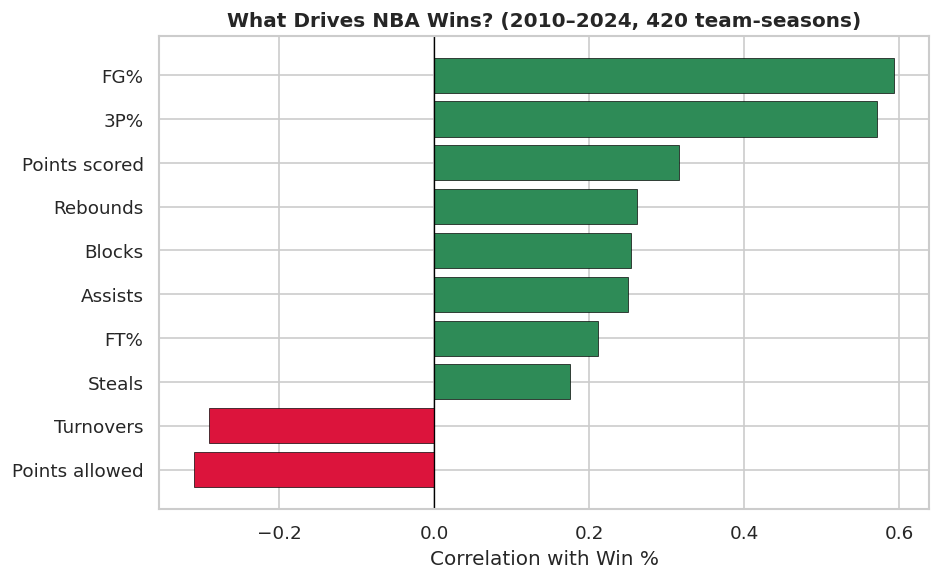

FG%               0.593
3P%               0.572
Points scored     0.316
Points allowed   -0.310
Turnovers        -0.291
Rebounds          0.261
Blocks            0.255
Assists           0.250
FT%               0.211
Steals            0.175
Name: WIN_PCT, dtype: float64


In [ ]:
# ============================================================
# What drives wins? (correlation map)
# Centerpiece result.
# ============================================================
labels = {'FG_PCT':'FG%', 'FG3_PCT':'3P%', 'FT_PCT':'FT%', 'PTS':'Points scored',
          'PTS_ALLOWED':'Points allowed', 'TOV':'Turnovers', 'REB':'Rebounds','AST':'Assists',
          'STL':'Steals', 'BLK':'Blocks'}

corr = (team_season[list(labels) + ['WIN_PCT']]
        .corr()['WIN_PCT'].drop('WIN_PCT').rename(labels).sort_values())

plt.figure(figsize=(8, 5))
colors = ['crimson' if v < 0 else 'seagreen' for v in corr]
plt.barh(corr.index, corr.values, color=colors, edgecolor='black', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Win %')
plt.title('What Drives NBA Wins? (2010–2024, 420 team-seasons)', fontweight='bold')
plt.tight_layout()
plt.show()

print(corr.sort_values(key=abs, ascending=False).round(3))

## Offense vs defense: which matters more?
Having seen that scoring and points allowed both relate to winning, we now compare them head-to-head to answer a classic question: is success built more on offense or defense? We compute two correlations with win percentage, one for points scored (offense) and one for points allowed (defense), and plot each as a scatter of team-seasons with a fitted regression line (via np.polyfit) showing the overall trend. The two panels share a y-axis so the relationships can be compared directly.


The result is stymmetrical(ish): offense correlates with winning at r = +0.316 and defense at r = −0.310. The opposite signs are expected, scoring more helps, allowing more hurts, but what matters is that the magnitudes are nearly identical. Neither end of the floor dominates, winning teams are built roughly equally on scoring efficiently and on preventing the opponent from doing the same. This is a clean, quantified counterpoint to the common claim that "defense wins championships"- the data suggests offense pulls just as hard.

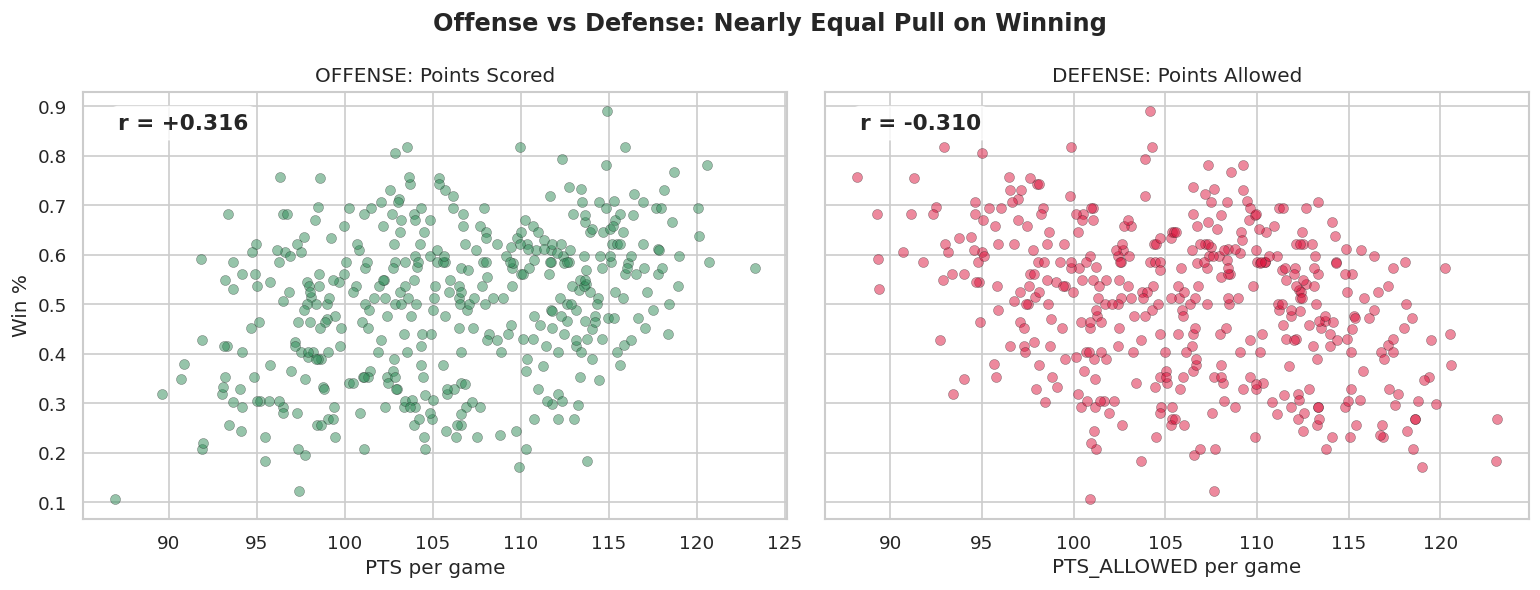

Offense r = +0.316   |   Defense r = -0.310   → near-identical magnitude


In [ ]:
# ============================================================
# Offense vs Defense — which matters more? (Pearson correlation)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

r_off = team_season['PTS'].corr(team_season['WIN_PCT'])
r_def = team_season['PTS_ALLOWED'].corr(team_season['WIN_PCT'])

for ax, col, title, r, color in [
    (axes[0], 'PTS', 'OFFENSE: Points Scored', r_off, 'seagreen'),
    (axes[1], 'PTS_ALLOWED', 'DEFENSE: Points Allowed', r_def, 'crimson')]:
    ax.scatter(team_season[col], team_season['WIN_PCT'],
               alpha=0.5, color=color, edgecolor='k', linewidth=0.3)
    # annotate Pearson r directly on the plot
    ax.text(0.05, 0.95, f'r = {r:+.3f}', transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set(title=title, xlabel=f'{col} per game')

axes[0].set_ylabel('Win %')
plt.suptitle('Offense vs Defense: Nearly Equal Pull on Winning', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Offense r = {r_off:+.3f}   |   Defense r = {r_def:+.3f}   "
      f"→ near-identical magnitude")

##The three-point revolution
The previous results showed that shooting efficiency drives winning more than raw scoring volume. If efficiency is what matters, has the league actually changed its behavior to chase the most efficient shot- the three-pointer? We group the team-seasons by year and take the league-average three-point attempts per game in each season, then plot that average over time as a line with a shaded area beneath it to emphasize the trend.

The growth is massive: three-point attempts rose from 18.0 per game in 2010-11 to 35.1 in 2023–24, an increase of roughly 95%- the league nearly doubled its reliance on the shot in just fourteen years. This trend ties the whole analysis together: it is the historical, real-world counterpart to our statistical finding. Teams didn't just happen to shoot more threes- they progressively reorganized how they play around the efficiency advantage that our correlation analysis surfaced. The shift in how points are scored is the story behind the numbers.


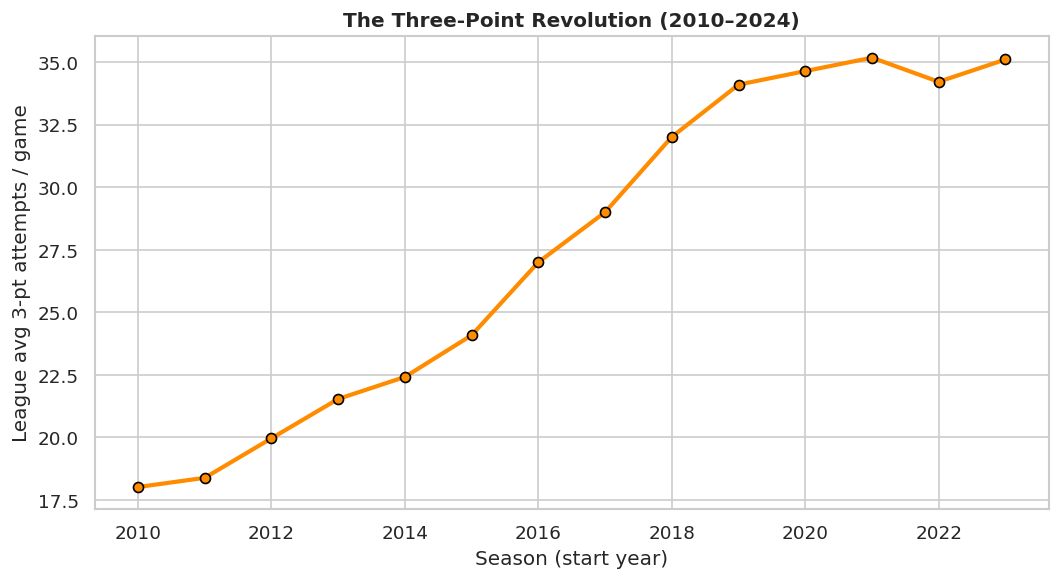

3PT attempts/game: 18.0 (2010-11) → 35.1 (2023-24)  =  +95%


In [ ]:
# ============================================================
# The three-point revolution
# ============================================================
trend = team_season.groupby('SEASON_START')['FG3A'].mean()

plt.figure(figsize=(9, 5))
plt.plot(trend.index, trend.values, marker='o', linewidth=2.5,
         color='darkorange', markeredgecolor='black')
plt.title('The Three-Point Revolution (2010–2024)', fontweight='bold')
plt.xlabel('Season (start year)')
plt.ylabel('League avg 3-pt attempts / game')
plt.tight_layout()
plt.show()

print(f"3PT attempts/game: {trend.iloc[0]:.1f} (2010-11) → "
      f"{trend.iloc[-1]:.1f} (2023-24)  =  +{100*(trend.iloc[-1]/trend.iloc[0]-1):.0f}%")

## Preliminary conclusions
All four findings point to one theme - efficiency over volume:

- Shooting efficiency drives winning. FG% (r = .59) and 3P% (r = .57) relate to winning far more strongly than raw points scored (r = .32) how a team scores matters more than how much.
- Turnovers are the biggest negative factor (r = −.29). Wasting possessions directly costs scoring chances.
- Offense and defense matter almost equally (scored r = +.32 vs allowed r = −.31), qualifying the usual "defense wins championships" intuition.
- The game fundamentally changed. Three-point attempts nearly doubled (+95%) over the era - the league physically reorganized itself around the efficiency advantage the data reveals.

_These conclusions are preliminary: the analysis rests on bivariate correlations, which measure association, not causation. Next steps for the full paper: multiple regression with an interaction term, era-split significance tests, and playoff/winning-season classification._

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ============================================================
# 1. Load Data and Prepare Dataset
# ============================================================
URL = "https://raw.githubusercontent.com/NocturneBear/NBA-Data-2010-2024/main/regular_season_totals_2010_2024.csv"
games = pd.read_csv(URL, low_memory=False)

# Derive points allowed and binary win indicator
games['PTS_ALLOWED'] = games['PTS'] - games['PLUS_MINUS']
games['WIN'] = (games['WL'] == 'W').astype(int)

# Aggregate to team-season level
team_season = games.groupby(['SEASON_YEAR', 'TEAM_ABBREVIATION']).agg(
    GP=('WIN', 'count'), WINS=('WIN', 'sum'),
    PTS=('PTS', 'mean'), PTS_ALLOWED=('PTS_ALLOWED', 'mean'),
    FG_PCT=('FG_PCT', 'mean'), FG3_PCT=('FG3_PCT', 'mean'),
    FT_PCT=('FT_PCT', 'mean'), FG3A=('FG3A', 'mean'),
    REB=('REB', 'mean'), AST=('AST', 'mean'),
    TOV=('TOV', 'mean'), STL=('STL', 'mean'), BLK=('BLK', 'mean')
).reset_index()

# Define dependent variable and season start year for era shifts
team_season['WIN_PCT'] = team_season['WINS'] / team_season['GP']
team_season['SEASON_START'] = team_season['SEASON_YEAR'].str[:4].astype(int)

# ============================================================
# 2. Formal Statistical Testing: Two-Sided Tests & Confidence Intervals
# ============================================================
metrics = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'PTS', 'PTS_ALLOWED', 'TOV', 'REB', 'AST', 'STL', 'BLK']
results = []
alpha = 0.05
n = len(team_season)

for metric in metrics:
    # Pearson test: correlation (r) and raw p-value
    r, p_val = stats.pearsonr(team_season[metric], team_season['WIN_PCT'])

    # Calculate Confidence Interval using Fisher's Z transform
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_lower = np.tanh(z - z_crit * se)
    ci_upper = np.tanh(z + z_crit * se)

    results.append({
        'Metric': metric,
        'Correlation (r)': r,
        'p-value': p_val,
        'CI Lower (95%)': ci_lower,
        'CI Upper (95%)': ci_upper
    })

results_df = pd.DataFrame(results)

# ============================================================
# 3. Multiple Comparisons Correction - Bonferroni
# ============================================================
# multipletests corrects the p-values to control the family-wise Type I error rate
reject, pvals_corrected, _, _ = multipletests(results_df['p-value'], alpha=alpha, method='bonferroni')

results_df['Corrected p-value'] = pvals_corrected
results_df['Reject H0?'] = reject

# Sort table by correlation strength (absolute value)
results_df = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False).reset_index(drop=True)

# Display the final formatted table
print("Bivariate Analysis Results with Bonferroni Correction:")
display(results_df.round(4))

Bivariate Analysis Results with Bonferroni Correction:


,Metric,Correlation (r),p-value,CI Lower (95%),CI Upper (95%),Corrected p-value,Reject H0?
0,FG_PCT,0.5934,0.0000,0.5277,0.6521,0.0000,True
1,FG3_PCT,0.5718,0.0000,0.5037,0.6329,0.0000,True
2,PTS,0.3161,0.0000,0.2273,0.3997,0.0000,True
3,PTS_ALLOWED,-0.3099,0.0000,-0.3939,-0.2207,0.0000,True
4,TOV,-0.2910,0.0000,-0.3762,-0.2009,0.0000,True
5,REB,0.2614,0.0000,0.1699,0.3484,0.0000,True
6,BLK,0.2546,0.0000,0.1629,0.3419,0.0000,True
7,AST,0.2502,0.0000,0.1584,0.3378,0.0000,True
8,FT_PCT,0.2110,0.0000,0.1177,0.3006,0.0001,True
9,STL,0.1746,0.0003,0.0802,0.2658,0.0033,True


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# ============================================================
# Define Eras Based on Season Start Year
# ============================================================
era1 = team_season[team_season['SEASON_START'] < 2015]['FG3A']  # Pre-Revolution (2010-2014)
era2 = team_season[team_season['SEASON_START'] >= 2015]['FG3A'] # Post-Revolution (2015-2023)

print("--- Distribution & Goodness of Fit ---")
# D'Agostino's K-squared test for normality
stat_norm, p_norm = stats.normaltest(team_season['FG3A'])
if p_norm < 0.05:
    print(f"Normality Test: p-value = {p_norm:.4f} -> The overall distribution of 3PA is NOT strictly normal (likely bimodal due to the era shift!).")
else:
    print(f"Normality Test: p-value = {p_norm:.4f} -> The distribution of 3PA appears normal.")

print("\n--- Independent Samples T-Test (One-Sided) ---")
# Calculate means
mean_era1 = era1.mean()
mean_era2 = era2.mean()
print(f"Mean 3-Point Attempts (2010-2014): {mean_era1:.2f}")
print(f"Mean 3-Point Attempts (2015-2023): {mean_era2:.2f}")

# Welch's t-test (assuming unequal variances)
t_stat, p_val_ttest = stats.ttest_ind(era1, era2, equal_var=False, alternative='less')
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value (One-Sided): {p_val_ttest:.4e}")

if p_val_ttest < 0.05:
    print("Conclusion: Reject H0! There is a statistically significant INCREASE in 3-point attempts in the modern era.")
else:
    print("Conclusion: Fail to reject H0.")

print("\n--- Power of the Test (1 - Beta) ---")
# Calculate Effect Size (Cohen's d)
pooled_std = np.sqrt(((len(era1)-1)*era1.var() + (len(era2)-1)*era2.var()) / (len(era1) + len(era2) - 2))
effect_size = (mean_era2 - mean_era1) / pooled_std

# Calculate Power
power_analysis = TTestIndPower()
power = power_analysis.solve_power(effect_size=effect_size, nobs1=len(era1), ratio=len(era2)/len(era1), alpha=0.05, alternative='larger')

print(f"Effect Size (Cohen's d): {effect_size:.2f}")
print(f"Statistical Power (1 - Beta): {power:.4f}")
if power > 0.8:
    print("The test has excellent power (>80%), meaning the probability of a Type II error is very low.")

--- Distribution & Goodness of Fit ---
Normality Test: p-value = 0.0000 -> The overall distribution of 3PA is NOT strictly normal (likely bimodal due to the era shift!).

--- Independent Samples T-Test (One-Sided) ---
Mean 3-Point Attempts (2010-2014): 20.06
Mean 3-Point Attempts (2015-2023): 31.70
T-statistic: -25.3641
p-value (One-Sided): 1.4362e-84
Conclusion: Reject H0! There is a statistically significant INCREASE in 3-point attempts in the modern era.

--- Power of the Test (1 - Beta) ---
Effect Size (Cohen's d): 2.37
Statistical Power (1 - Beta): 1.0000
The test has excellent power (>80%), meaning the probability of a Type II error is very low.


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("======================================================")
print(" 1. MULTIPLE LINEAR REGRESSION & INTERACTION TERM")
print("======================================================\n")

# Build regression formula. Dependent variable: WIN_PCT
# Independent variables: 3P%, 3PA, Turnovers, Rebounds, Points Allowed, and the interaction term
formula = 'WIN_PCT ~ FG3_PCT + FG3A + TOV + REB + PTS_ALLOWED + FG3_PCT:FG3A'

# Run the OLS model
model = smf.ols(formula=formula, data=team_season).fit()

# Print academic summary (includes F-test, R-squared, and p-values)
print(model.summary())

print("\n\n======================================================")
print(" 2. CLASSIFICATION & MACHINE LEARNING EVALUATION")
print("======================================================\n")

# Define target variable: Playoff caliber = 50% win rate or higher
team_season['PLAYOFF_CALIBER'] = (team_season['WIN_PCT'] >= 0.5).astype(int)

# Select features for the model
X = team_season[['FG_PCT', 'FG3_PCT', 'TOV', 'PTS_ALLOWED', 'REB']]
y = team_season['PLAYOFF_CALIBER']

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression classifier
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Predict on test set
y_pred = classifier.predict(X_test)

# Calculate and print evaluation metrics
print("Classification Metrics on Test Set (Predicting Playoff Teams):")
print("-" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")

# Confusion Matrix for Type I and Type II errors
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"True Negatives: {cm[0][0]}  |  False Positives (Type I Error): {cm[0][1]}")
print(f"False Negatives (Type II): {cm[1][0]} |  True Positives: {cm[1][1]}")

 1. MULTIPLE LINEAR REGRESSION & INTERACTION TERM

                            OLS Regression Results                            
Dep. Variable:                WIN_PCT   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     125.2
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.05e-89
Time:                        02:21:11   Log-Likelihood:                 421.09
No. Observations:                 420   AIC:                            -828.2
Df Residuals:                     413   BIC:                            -799.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [ ]:
import numpy as np
from scipy.stats import chi2
import statsmodels.formula.api as smf

print("======================================================")
print(" 1. GLRT (Generalized Likelihood Ratio Test)")
print("======================================================\n")
# Restricted model: Excludes 3-point metrics
formula_restricted = 'WIN_PCT ~ TOV + REB + PTS_ALLOWED'
model_restricted = smf.ols(formula=formula_restricted, data=team_season).fit()

# Full model: Includes 3-point metrics and interaction term (from Block 3)
formula_full = 'WIN_PCT ~ FG3_PCT + FG3A + TOV + REB + PTS_ALLOWED + FG3_PCT:FG3A'
model_full = smf.ols(formula=formula_full, data=team_season).fit()

# Calculate GLRT statistic
ll_rest = model_restricted.llf
ll_full = model_full.llf
glrt_stat = -2 * (ll_rest - ll_full)

# Calculate degrees of freedom and p-value
df_diff = model_full.df_model - model_restricted.df_model
p_value_glrt = chi2.sf(glrt_stat, df_diff)

print(f"Log-Likelihood (Restricted Model): {ll_rest:.2f}")
print(f"Log-Likelihood (Full Model):       {ll_full:.2f}")
print(f"GLRT Test Statistic:               {glrt_stat:.2f}")
print(f"p-value:                           {p_value_glrt:.4e}")
if p_value_glrt < 0.05:
    print("Conclusion: Reject H0. The 3-point statistics significantly improve model fit (GLRT).")

print("\n======================================================")
print(" 2. WALD SEQUENTIAL PROBABILITY RATIO TEST (SPRT) & STOPPING TIME")
print("======================================================\n")
# Simulate a sequence of games for a true elite team (75% win probability)
np.random.seed(42)
season_results = np.random.binomial(1, 0.75, 82) # 82 games in a standard season

# Define hypotheses for Wald SPRT
p0 = 0.5 # H0: Average team
p1 = 0.7 # H1: Elite team
alpha = 0.05 # Type I error limit
beta = 0.05  # Type II error limit

# Calculate stopping boundaries
A = np.log((1 - beta) / alpha)
B = np.log(beta / (1 - alpha))

log_lambda_n = 0
stopping_time = None
decision = None

# Sequential testing across games
for n, win in enumerate(season_results, start=1):
    if win == 1:
        log_lambda_n += np.log(p1 / p0)
    else:
        log_lambda_n += np.log((1 - p1) / (1 - p0))

    # Check stopping criteria
    if log_lambda_n >= A:
        stopping_time = n
        decision = "Reject H0 (Declare Elite Team)"
        break
    elif log_lambda_n <= B:
        stopping_time = n
        decision = "Accept H0 (Declare Average Team)"
        break

if stopping_time:
    print(f"Stopping Time: {stopping_time} games.")
    print(f"Decision: {decision}")
else:
    print("Season ended without crossing the Wald boundaries.")

 1. GLRT (Generalized Likelihood Ratio Test)

Log-Likelihood (Restricted Model): 287.41
Log-Likelihood (Full Model):       421.09
GLRT Test Statistic:               267.35
p-value:                           1.1536e-57
Conclusion: Reject H0. The 3-point statistics significantly improve model fit (GLRT).

 2. WALD SEQUENTIAL PROBABILITY RATIO TEST (SPRT) & STOPPING TIME

Stopping Time: 19 games.
Decision: Reject H0 (Declare Elite Team)
